<a href="https://www.kaggle.com/code/mahmoudashrey/heart-disease?scriptVersionId=349329158" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.columns

df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

df = df.drop_duplicates()

df.shape

(302, 14)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [9]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

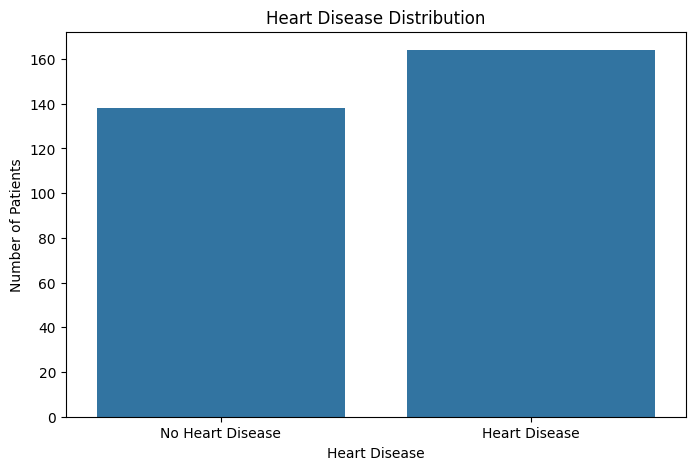

In [10]:
plt.figure(figsize = (8, 5))

sns.countplot(data = df, x = "target")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])

plt.show()

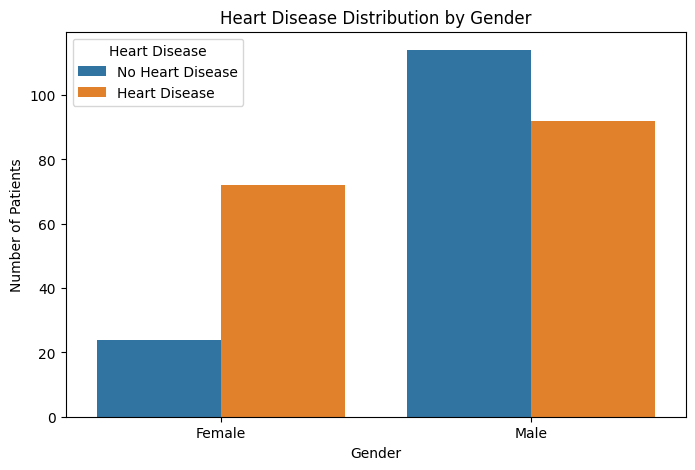

In [11]:
plt.figure(figsize = (8, 5))

sns.countplot(data = df, x = "sex", hue = "target")

plt.title("Heart Disease Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.xticks([0, 1], ["Female", "Male"])

plt.legend(
    title = "Heart Disease",
    labels = ["No Heart Disease", "Heart Disease"]
)

plt.show()

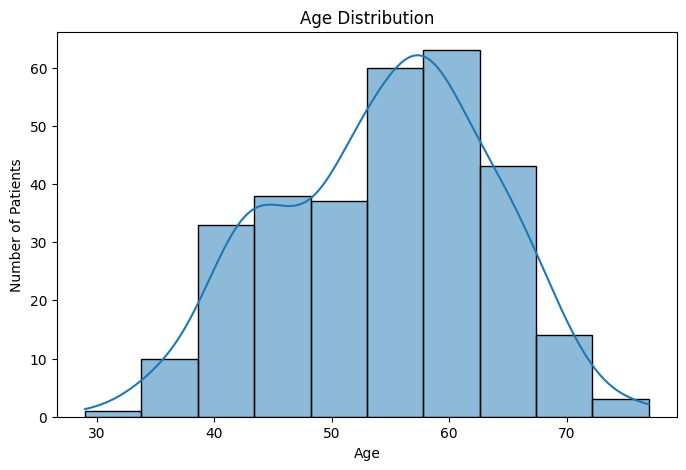

In [12]:
plt.figure(figsize = (8, 5))

sns.histplot(data = df, x = "age", bins = 10, kde = True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

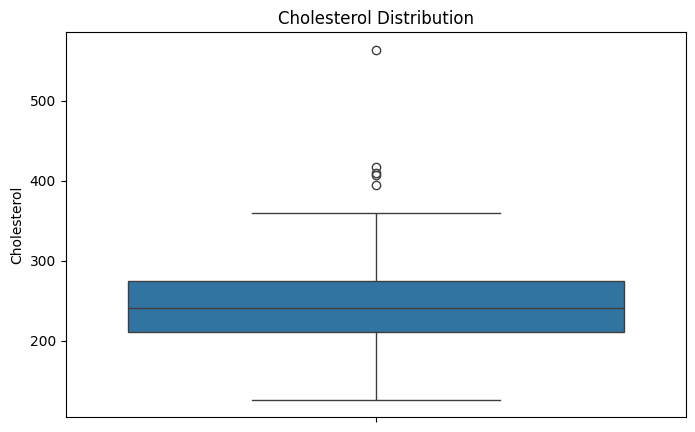

In [13]:
plt.figure(figsize = (8, 5))

sns.boxplot(data = df, y = "chol")

plt.title("Cholesterol Distribution")
plt.ylabel("Cholesterol")

plt.show()

In [14]:
avg_cholesterol = df.groupby("target")["chol"].mean()

avg_cholesterol




target
0    251.086957
1    242.640244
Name: chol, dtype: float64

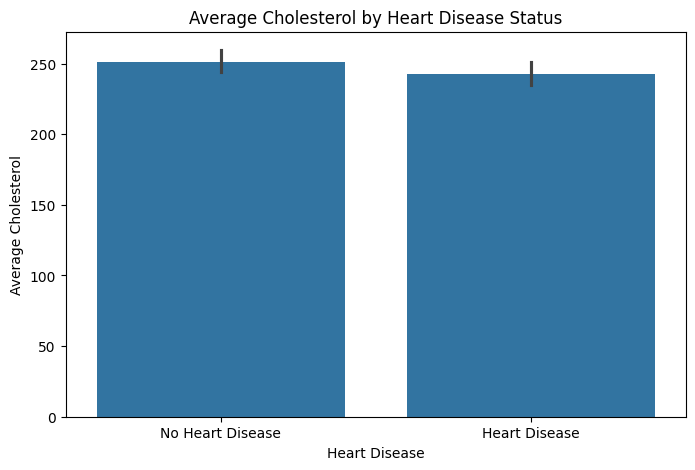

In [15]:
plt.figure(figsize = (8, 5))

sns.barplot(data = df, x = "target", y = "chol", estimator = "mean")

plt.title("Average Cholesterol by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Average Cholesterol")

plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])

plt.show()

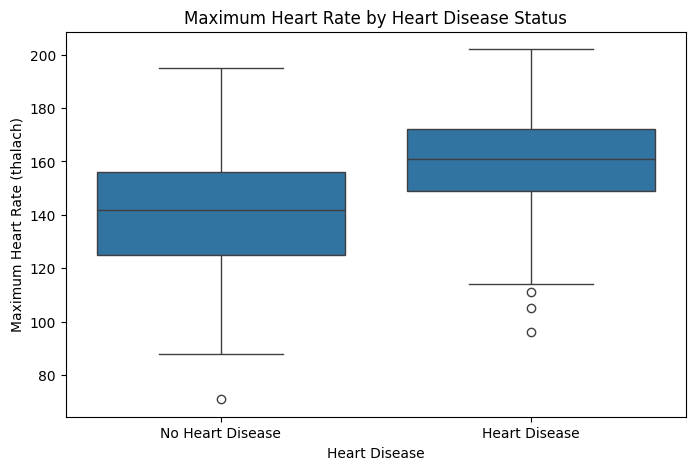

In [16]:
plt.figure(figsize = (8, 5))

sns.boxplot(data = df, x = "target", y = "thalach")

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate (thalach)")

plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])

plt.show()

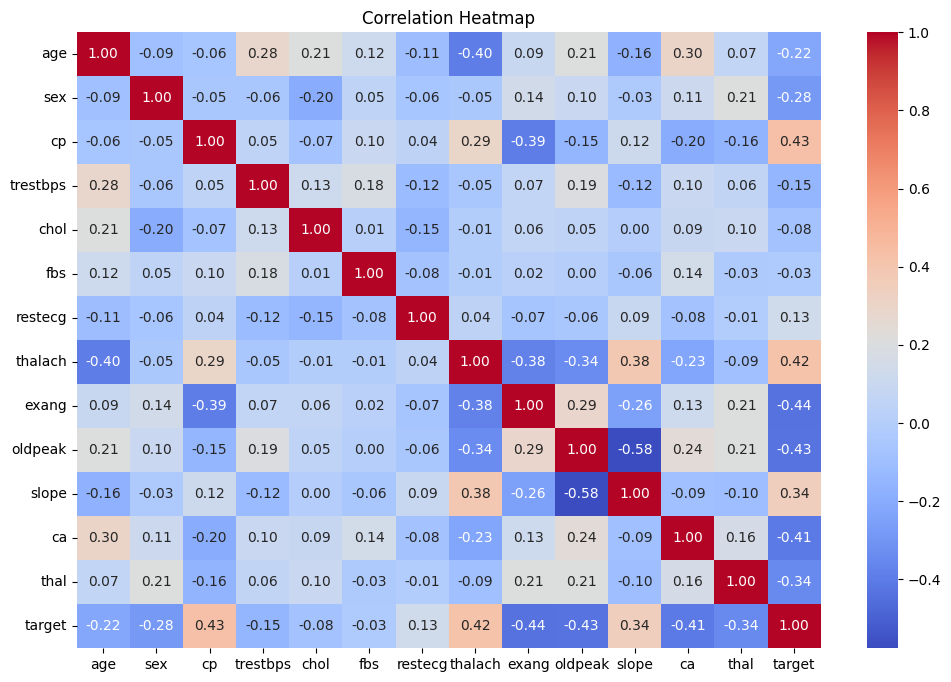

In [17]:
correlation_matrix = df.corr(numeric_only = True)

plt.figure(figsize = (12, 8))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
target_correlation = (
    df.corr(numeric_only = True)["target"]
    .sort_values(ascending = False)
)

print(target_correlation)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64
